# Model Analysis — IT News Classifier

This notebook evaluates how well the zero-shot classifier (`valhalla/distilbart-mnli-12-3`) is performing on real RSS articles.

**What we analyse:**
- The model parameters (label weights, recency decay, threshold)
- Score distributions across all articles
- Category breakdown and sample articles per category
- Borderline cases near the filtering threshold
- A manual evaluation table where you can judge if the model is right or wrong

## 0. Install dependencies
Only needed once — skip if already installed.

In [1]:
%pip install pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup — load data from the database

In [7]:
import math
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 120)

DB_PATH = "news.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT
        id, source, title, published_at, ingested_at,
        category, importance_score, recency_score, final_score, is_filtered
    FROM articles
    ORDER BY final_score DESC
""", conn)
conn.close()

df["published_at"] = pd.to_datetime(df["published_at"], utc=True)
df["ingested_at"]  = pd.to_datetime(df["ingested_at"],  utc=True)
df["is_filtered"]  = df["is_filtered"].astype(bool)

print(f"Total articles in DB: {len(df)}")
print(f"  Passed filter (is_filtered=True):  {df['is_filtered'].sum()}")
print(f"  Rejected (is_filtered=False):      {(~df['is_filtered']).sum()}")

Total articles in DB: 205
  Passed filter (is_filtered=True):  167
  Rejected (is_filtered=False):      38


## 2. Model parameters

These are the values hard-coded in `app/classifier.py`. Understanding them is key to evaluating whether the model behaves correctly.

In [8]:
# ── Label weights ────────────────────────────────────────────────────────────
LABEL_WEIGHTS = {
    "cybersecurity incident or data breach":  1.0,
    "system outage or service disruption":    1.0,
    "critical software bug or vulnerability": 0.9,
    "software release or patch":              0.5,
    "general technology news":                0.2,
}
IMPORTANCE_THRESHOLD = 0.5

# ── Recency decay ─────────────────────────────────────────────────────────────
RECENCY_HALF_LIFE_HOURS = 48
RECENCY_LAMBDA = math.log(2) / RECENCY_HALF_LIFE_HOURS

print("=== Label weights ===")
weights_df = pd.DataFrame(list(LABEL_WEIGHTS.items()), columns=["Category", "Weight"])
weights_df["Min importance if dominant"] = weights_df["Weight"].apply(
    lambda w: f"{w * 1.0:.1f}  {'✅ PASS' if w > IMPORTANCE_THRESHOLD else '❌ FAIL'}"
)
display(weights_df)

print(f"\nImportance threshold: {IMPORTANCE_THRESHOLD}")
print(f"Recency half-life: {RECENCY_HALF_LIFE_HOURS}h  (λ = {RECENCY_LAMBDA:.4f})")
print(f"\nImportance score formula:  sum(confidence_i × weight_i)  for all labels i")
print(f"Final score formula:        importance_score × recency_score")

=== Label weights ===


,Category,Weight,Min importance if dominant
0,cybersecurity incident or data breach,1.0,1.0 ✅ PASS
1,system outage or service disruption,1.0,1.0 ✅ PASS
2,critical software bug or vulnerability,0.9,0.9 ✅ PASS
3,software release or patch,0.5,0.5 ❌ FAIL
4,general technology news,0.2,0.2 ❌ FAIL



Importance threshold: 0.5
Recency half-life: 48h  (λ = 0.0144)

Importance score formula:  sum(confidence_i × weight_i)  for all labels i
Final score formula:        importance_score × recency_score


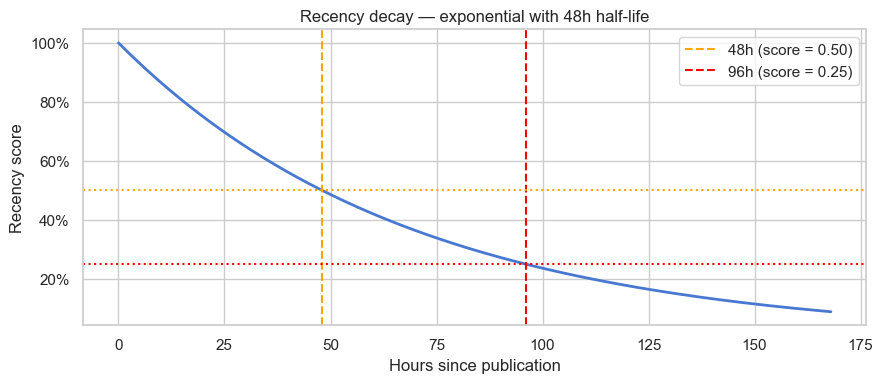

Takeaway: an article older than 4 days has its final_score cut to 25% of its importance_score.


In [9]:
# ── Recency decay curve ───────────────────────────────────────────────────────
hours = np.linspace(0, 168, 500)  # 0 to 7 days
recency = np.exp(-RECENCY_LAMBDA * hours)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hours, recency, linewidth=2)
ax.axvline(48,  color="orange", linestyle="--", label="48h (score = 0.50)")
ax.axvline(96,  color="red",    linestyle="--", label="96h (score = 0.25)")
ax.axhline(0.5, color="orange", linestyle=":")
ax.axhline(0.25, color="red",   linestyle=":")
ax.set_xlabel("Hours since publication")
ax.set_ylabel("Recency score")
ax.set_title("Recency decay — exponential with 48h half-life")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print("Takeaway: an article older than 4 days has its final_score cut to 25% of its importance_score.")

## 3. Dataset overview

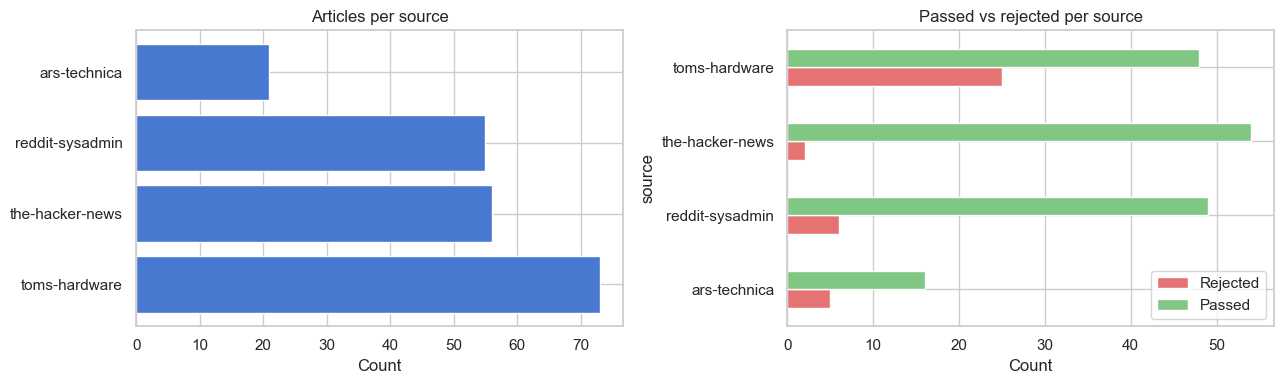

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Articles per source
source_counts = df["source"].value_counts()
axes[0].barh(source_counts.index, source_counts.values)
axes[0].set_title("Articles per source")
axes[0].set_xlabel("Count")

# Filtered vs rejected per source
pivot = df.groupby(["source", "is_filtered"]).size().unstack(fill_value=0)
pivot.columns = ["Rejected", "Passed"]
pivot.plot(kind="barh", ax=axes[1], color=["#e57373", "#81c784"])
axes[1].set_title("Passed vs rejected per source")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

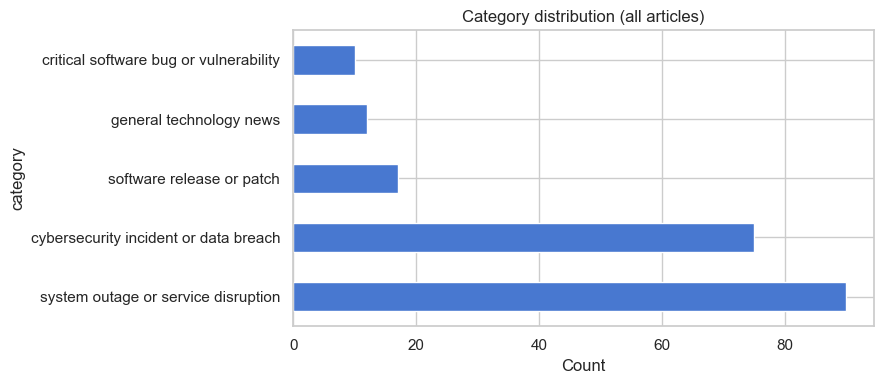


Category counts:


,count
category,
system outage or service disruption,90
cybersecurity incident or data breach,75
software release or patch,17
general technology news,12
critical software bug or vulnerability,10


In [11]:
# Category distribution across ALL articles
cat_counts = df["category"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
cat_counts.plot(kind="barh", ax=ax)
ax.set_title("Category distribution (all articles)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

print("\nCategory counts:")
display(cat_counts.to_frame("count"))

## 4. Score distributions

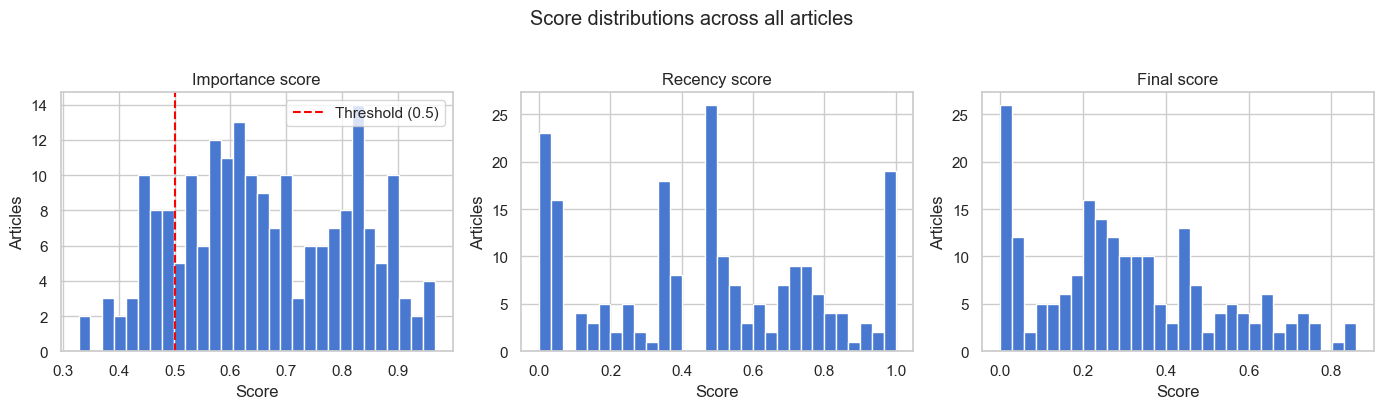


Summary statistics:


,importance_score,recency_score,final_score
count,204.000,204.000,204.000
mean,0.662,0.471,0.307
std,0.154,0.311,0.220
min,0.328,0.000,0.000
25%,0.542,0.218,0.158
50%,0.644,0.485,0.281
75%,0.803,0.716,0.450
max,0.967,1.000,0.860


In [12]:
scored = df.dropna(subset=["importance_score", "recency_score", "final_score"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title in zip(axes,
    ["importance_score", "recency_score", "final_score"],
    ["Importance score", "Recency score", "Final score"]):
    ax.hist(scored[col], bins=30, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Articles")
    if col == "importance_score":
        ax.axvline(IMPORTANCE_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({IMPORTANCE_THRESHOLD})")
        ax.legend()

plt.suptitle("Score distributions across all articles", y=1.02)
plt.tight_layout()
plt.show()

print("\nSummary statistics:")
display(scored[["importance_score", "recency_score", "final_score"]].describe().round(3))

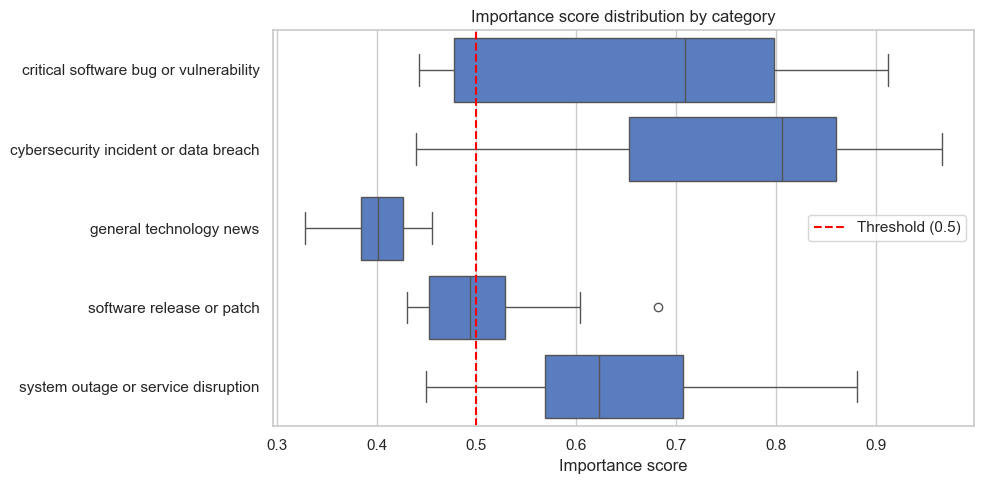

In [13]:
# Importance score by category — box plot
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(df["category"].dropna().unique())
sns.boxplot(data=scored, y="category", x="importance_score", order=order, ax=ax)
ax.axvline(IMPORTANCE_THRESHOLD, color="red", linestyle="--", label=f"Threshold ({IMPORTANCE_THRESHOLD})")
ax.set_title("Importance score distribution by category")
ax.set_xlabel("Importance score")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sample articles per category — is the model right?

For each category, we show a sample of articles. Read the titles and ask yourself:
- Does the category make sense for this title?
- Does the importance score feel right given the label weights?

Add your own `is_correct` column at the end of this section.

In [14]:
SAMPLE_PER_CATEGORY = 5

cols_to_show = ["title", "source", "importance_score", "recency_score", "final_score", "is_filtered"]

for category in sorted(df["category"].dropna().unique()):
    subset = df[df["category"] == category].sort_values("importance_score", ascending=False)
    sample = subset.head(SAMPLE_PER_CATEGORY)[cols_to_show].copy()
    sample = sample.round(3)
    print(f"\n{'='*80}")
    print(f"Category: {category}  (weight = {LABEL_WEIGHTS[category]})  — {len(subset)} articles total")
    print(f"{'='*80}")
    display(sample)


Category: critical software bug or vulnerability  (weight = 0.9)  — 10 articles total


,title,source,importance_score,recency_score,final_score,is_filtered
92,Cisco SD-WAN Zero-Day CVE-2026-20127 Exploited Since 2023 for Admin Access,the-hacker-news,0.912,0.323,0.295,True
137,CISA Confirms Active Exploitation of FileZen CVE-2026-25108 Vulnerability,the-hacker-news,0.900,0.226,0.203,True
143,SolarWinds Patches 4 Critical Serv-U 15.5 Flaws Allowing Root Code Execution,the-hacker-news,0.805,0.232,0.186,True
106,Expert Recommends: Prepare for PQC Right Now,the-hacker-news,0.777,0.352,0.274,True
160,Wormable XMRig Campaign Uses BYOVD Exploit and Time-Based Logic Bomb,the-hacker-news,0.754,0.136,0.102,True



Category: cybersecurity incident or data breach  (weight = 1.0)  — 75 articles total


,title,source,importance_score,recency_score,final_score,is_filtered
167,Identity Cyber Scores: The New Metric Shaping Cyber Insurance in 2026,the-hacker-news,0.967,0.043,0.042,True
165,AI-Assisted Threat Actor Compromises 600+ FortiGate Devices in 55 Countries,the-hacker-news,0.947,0.065,0.061,True
175,INTERPOL Operation Red Card 2.0 Arrests 651 in African Cybercrime Crackdown,the-hacker-news,0.946,0.034,0.032,True
112,Google Disrupts UNC2814 GRIDTIDE Campaign After 53 Breaches Across 42 Countries,the-hacker-news,0.946,0.270,0.256,True
44,ScarCruft Uses Zoho WorkDrive and USB Malware to Breach Air-Gapped Networks,the-hacker-news,0.940,0.502,0.473,True



Category: general technology news  (weight = 0.2)  — 12 articles total


,title,source,importance_score,recency_score,final_score,is_filtered
127,"Razer launches $130 laptop sleeve featuring two wireless charging pads — Base variant with no tech costs $80, suppor...",toms-hardware,0.455,0.493,0.224,False
203,"AI agents now have their own Reddit-style social network, and it's getting weird fast",ars-technica,0.442,0.000,0.000,False
146,SK hynix and SanDisk announce new High Bandwidth Flash — speedy HBF standard is targeted at inference AI servers,toms-hardware,0.435,0.398,0.173,False
73,Philips 34B1U5600CH – Does USB-C + HDMI work in 50/50 PBP with hardware KVM (no software)?,reddit-sysadmin,0.424,0.826,0.350,False
130,ISSCC 2026: AMD discloses how the Instinct MI355X doubled per-CU throughput despite lower compute unit count — 'We a...,toms-hardware,0.414,0.525,0.218,False



Category: software release or patch  (weight = 0.5)  — 17 articles total


,title,source,importance_score,recency_score,final_score,is_filtered
195,Microsoft releases urgent Office patch. Russian-state hackers pounce.,ars-technica,0.682,0.000,0.000,True
191,Patch Tuesday Megathread (2026-02-10),reddit-sysadmin,0.604,0.002,0.001,True
182,Microsoft Patches CVE-2026-26119 Privilege Escalation in Windows Admin Center,the-hacker-news,0.566,0.036,0.020,True
113,Razer Iskur V2 NewGen gaming chair review: A much-needed ‘cooler’ update to an already solid chair,toms-hardware,0.533,0.477,0.254,True
188,OpenAI sidesteps Nvidia with unusually fast coding model on plate-sized chips,ars-technica,0.529,0.003,0.002,True



Category: system outage or service disruption  (weight = 1.0)  — 90 articles total


,title,source,importance_score,recency_score,final_score,is_filtered
10,Best route to become a badass Windows performance troubleshooting expert?,reddit-sysadmin,0.881,0.816,0.719,True
0,Suggestion for a reliable DMARC reports ingestion service?,reddit-sysadmin,0.872,0.986,0.860,True
17,DLP policy not working in Outlook,reddit-sysadmin,0.865,0.753,0.651,True
1,Adobe Premiere Pro Error Code 0xc0000142,reddit-sysadmin,0.857,0.982,0.842,True
12,CMMC L2,reddit-sysadmin,0.842,0.840,0.707,True


## 6. Borderline cases — articles near the threshold

These are the most interesting cases: articles the model almost passed or almost rejected.
A human reviewer should pay special attention here.

In [15]:
MARGIN = 0.08  # look at articles within ±0.08 of the threshold

borderline = df[
    (df["importance_score"] >= IMPORTANCE_THRESHOLD - MARGIN) &
    (df["importance_score"] <= IMPORTANCE_THRESHOLD + MARGIN)
].sort_values("importance_score", ascending=False).copy()

print(f"Articles within ±{MARGIN} of threshold ({IMPORTANCE_THRESHOLD}): {len(borderline)}")

display(borderline[["title", "source", "category", "importance_score", "is_filtered"]]
        .round(3)
        .reset_index(drop=True))

Articles within ±0.08 of threshold (0.5): 59


,title,source,category,importance_score,is_filtered
0,Sophisticated Azure billing phishing email going around,reddit-sysadmin,cybersecurity incident or data breach,0.578,True
1,"OpenAI raises $110 billion in largest-ever private tech funding round, Nvidia throws in $30 billion — AI startup now...",toms-hardware,system outage or service disruption,0.578,True
2,"Nvidia warns of constrained supply of gaming GPUs, potentially signaling higher prices and shortages to come — 'we d...",toms-hardware,system outage or service disruption,0.577,True
3,EC-Council Expands AI Certification Portfolio to Strengthen U.S. AI Workforce Readiness and Security,the-hacker-news,cybersecurity incident or data breach,0.576,True
4,"Klevv Cras V RGB DDR5-9600 C46 2x24GB review: Binned for pure speed, not your wallet",toms-hardware,system outage or service disruption,0.574,True
5,"Shave $150 off the bill with this 32GB DDR5-6400 RAM and Asus Rog Strix B850 motherboard bundle, just $449 — or opt ...",toms-hardware,system outage or service disruption,0.571,True
6,"Inside Meta and AMD's $100 billion deal, and why AMD is giving up a slice of the company in return for GPU orders — ...",toms-hardware,system outage or service disruption,0.570,True
7,"The Nvidia GeForce3 launched 25 years ago — underappreciated at launch, its impact shaped the industry",toms-hardware,system outage or service disruption,0.569,True
8,Choose an Intel or AMD CPU and save up to $1200 on an RTX 5080-powered Omen Max 16 laptop — high-end gaming just go...,toms-hardware,system outage or service disruption,0.568,True
9,Microsoft Patches CVE-2026-26119 Privilege Escalation in Windows Admin Center,the-hacker-news,software release or patch,0.566,True


## 7. Model weakness — Reddit r/sysadmin misclassification

Looking at section 5, a clear pattern emerges: **virtually all Reddit r/sysadmin articles are misclassified**.

### Why it happens

Reddit r/sysadmin is a community forum, not a news source. Its posts are questions, advice requests, and discussions — not news events. Examples from our data:

- *"Suggestion for a reliable DMARC reports ingestion service?"*
- *"Best route to become a badass Windows performance troubleshooting expert?"*
- *"M365 Backup Options?"*
- *"How hard should I push for a promotion at a job I really like?"*

The zero-shot model has no choice but to pick one of the five existing labels. Since these posts often mention IT systems (Outlook, Azure, DLP…), the model forces them into **"system outage or service disruption"** or **"cybersecurity incident or data breach"** — both high-weight categories — giving them artificially high importance scores.

### The fix: add a new category

We should add a sixth label: **"IT community discussion or advice request"**

This gives the model a correct home for forum-style posts. With a low weight (e.g. `0.15`), these posts would score below the 0.5 threshold and be filtered out — which is the right behaviour.

In [ ]:
# All Reddit sysadmin articles — current (wrong) classifications
reddit_df = df[df["source"] == "reddit-sysadmin"][
    ["title", "category", "importance_score", "is_filtered"]
].sort_values("importance_score", ascending=False).copy().reset_index(drop=True)

print(f"Reddit r/sysadmin articles: {len(reddit_df)}")
print(f"  Currently passing filter: {reddit_df['is_filtered'].sum()} ({reddit_df['is_filtered'].mean()*100:.0f}%)")
print(f"\nCategory breakdown:")
display(reddit_df["category"].value_counts().to_frame("count"))
print()
display(reddit_df.round(3))

In [20]:
# Proposed updated label weights with the new category
NEW_LABEL_WEIGHTS = {
    "cybersecurity incident or data breach":    1.0,
    "system outage or service disruption":      1.0,
    "critical software bug or vulnerability":   0.9,
    "software release or patch":                0.5,
    "general technology news":                  0.2,
    "IT community discussion or advice request": 0.15,  # NEW — below threshold, will be filtered out
}

print("=== Updated label weights ===")
new_weights_df = pd.DataFrame(list(NEW_LABEL_WEIGHTS.items()), columns=["Category", "Weight"])
new_weights_df["Passes threshold?"] = new_weights_df["Weight"].apply(
    lambda w: "✅ PASS" if w > IMPORTANCE_THRESHOLD else "❌ FAIL"
)
new_weights_df["New?"] = ["", "", "", "", "", "NEW"]
display(new_weights_df)

print("""
Expected impact after re-classifying with this new label:
- Reddit r/sysadmin posts labelled as "IT community discussion" → importance ≈ 0.15 → filtered out
- Legitimate IT news from other sources is unaffected
- The model now has a semantically correct bucket for forum content
""")

=== Updated label weights ===


,Category,Weight,Passes threshold?,New?
0,cybersecurity incident or data breach,1.00,✅ PASS,
1,system outage or service disruption,1.00,✅ PASS,
2,critical software bug or vulnerability,0.90,✅ PASS,
3,software release or patch,0.50,❌ FAIL,
4,general technology news,0.20,❌ FAIL,
5,IT community discussion or advice request,0.15,❌ FAIL,NEW



Expected impact after re-classifying with this new label:
- Reddit r/sysadmin posts labelled as "IT community discussion" → importance ≈ 0.15 → filtered out
- Legitimate IT news from other sources is unaffected
- The model now has a semantically correct bucket for forum content



## 8. Top & bottom articles by final score

In [21]:
cols = ["title", "sourc e", "category", "importance_score", "recency_score", "final_score"]

print("=== Top 10 articles by final score ===")
display(df.head(10)[cols].round(3))

print("\n=== Bottom 10 articles by final score (that passed the filter) ===")
passed = df[df["is_filtered"]]
display(passed.tail(10)[cols].round(3))

=== Top 10 articles by final score ===


,title,source,category,importance_score,recency_score,final_score
0,Suggestion for a reliable DMARC reports ingestion service?,reddit-sysadmin,system outage or service disruption,0.872,0.986,0.860
1,Adobe Premiere Pro Error Code 0xc0000142,reddit-sysadmin,system outage or service disruption,0.857,0.982,0.842
2,"Am I Getting Fucked Friday, February, 27th 2026",reddit-sysadmin,system outage or service disruption,0.840,1.000,0.840
3,Duo Connection to Azure Down for us again,reddit-sysadmin,system outage or service disruption,0.837,0.971,0.813
4,M365 Backup Options?,reddit-sysadmin,system outage or service disruption,0.762,1.000,0.762
5,how would someone get caught using Ai tools outside of the network?,reddit-sysadmin,cybersecurity incident or data breach,0.746,1.000,0.746
6,"My ""I've made a massive mistake"" moment",reddit-sysadmin,cybersecurity incident or data breach,0.818,0.912,0.746
7,How hard should I push for a promotion at a job I really like?,reddit-sysadmin,system outage or service disruption,0.741,0.994,0.737
8,Anyone here running a private USA RDP instead of shared/cloud setups? Worth it long term?,reddit-sysadmin,system outage or service disruption,0.728,1.000,0.728
9,Company offers me a free flat,reddit-sysadmin,system outage or service disruption,0.739,0.981,0.725



=== Bottom 10 articles by final score (that passed the filter) ===


,title,source,category,importance_score,recency_score,final_score
189,"OpenAI researcher quits over ChatGPT ads, warns of ""Facebook"" path",ars-technica,cybersecurity incident or data breach,0.676,0.002,0.001
190,Once-hobbled Lumma Stealer is back with lures that are hard to resist,ars-technica,cybersecurity incident or data breach,0.648,0.002,0.001
191,Patch Tuesday Megathread (2026-02-10),reddit-sysadmin,software release or patch,0.604,0.002,0.001
192,Malicious packages for dYdX cryptocurrency exchange empties user wallets,ars-technica,cybersecurity incident or data breach,0.895,0.000,0.000
194,OpenAI is hoppin' mad about Anthropic's new Super Bowl TV ads,ars-technica,cybersecurity incident or data breach,0.543,0.000,0.000
195,Microsoft releases urgent Office patch. Russian-state hackers pounce.,ars-technica,software release or patch,0.682,0.000,0.000
197,"So yeah, I vibe-coded a log colorizer—and I feel good about it",ars-technica,system outage or service disruption,0.600,0.000,0.000
199,The rise of Moltbook suggests viral AI prompts may be the next big security threat,ars-technica,cybersecurity incident or data breach,0.697,0.000,0.000
200,Nvidia's $100 billion OpenAI deal has seemingly vanished,ars-technica,system outage or service disruption,0.594,0.000,0.000
201,Notepad++ users take note: It's time to check if you're hacked,ars-technica,cybersecurity incident or data breach,0.829,0.000,0.000
